In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.transforms import blended_transform_factory

from scipy.io import wavfile
import os

letters = 'abcdefghijklmnopqrstuvwxyz'
%matplotlib inline

In [2]:
# plt.rcParams['font.size']      = 18
plt.rcParams['font.weight']       = 'bold'
plt.rcParams['axes.labelweight']  = 'bold'
plt.rcParams['axes.titleweight']  = 'bold'
plt.rcParams['axes.grid']      = True
plt.rcParams['axes.xmargin']   = 0
plt.rcParams['axes.ymargin']   = 0.5

plt.rcParams['grid.linestyle'] = ':'

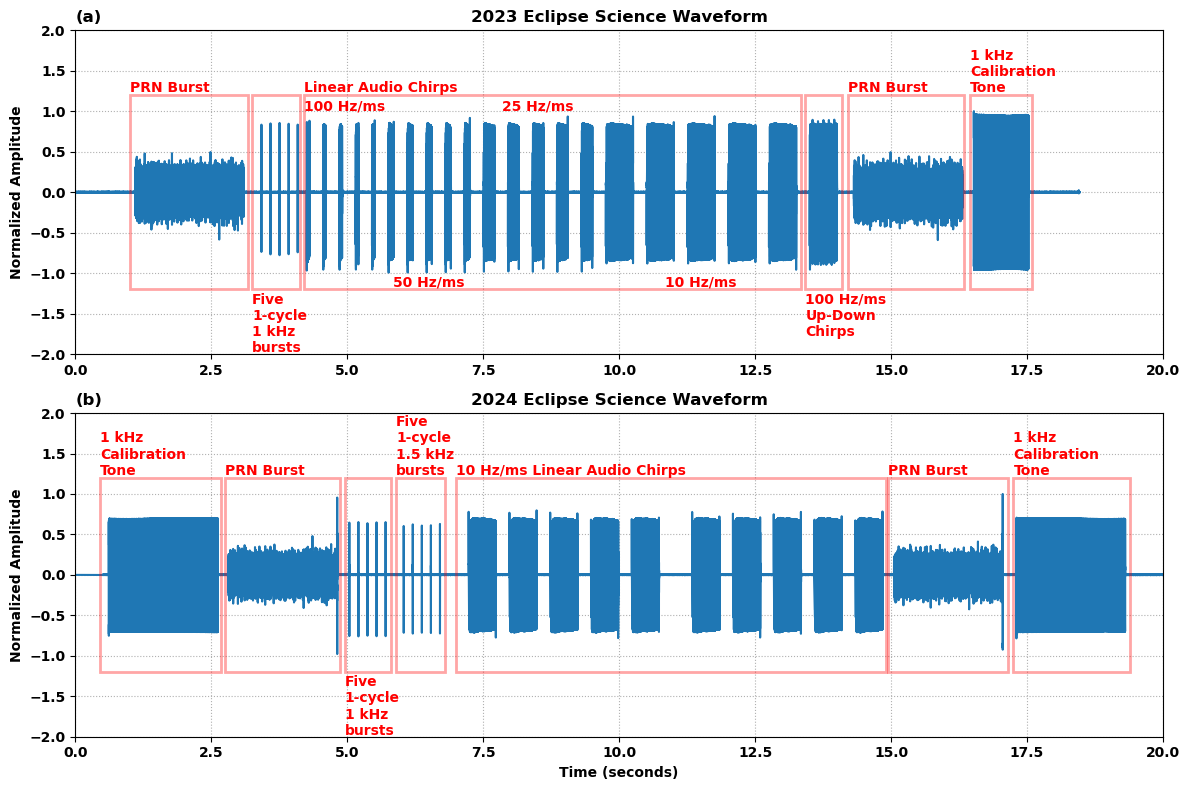

In [126]:
wvform = {}
wvform[2023] = {
    'fname': 'voicetx4_2023_eclipse_science_payload_only.wav'
}

wvform[2024] = {
    'fname': 'voicetx1_2024_eclipse_transmit_file.wav'
}


nrows = len(wvform)
fig = plt.figure(figsize=(12, 4*nrows))

for pinx,(year, wv_dct) in enumerate(wvform.items()):
    fname = wv_dct['fname']
    file_path = os.path.join('wav', fname)
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File {file_path} does not exist.")

    sample_rate, data = wavfile.read(file_path)

    duration = len(data) / sample_rate
    time     = np.linspace(0, duration, num=len(data))

    if len(data.shape) == 2:
        print('WARNING: Using only one channel of stereo data.')
        data = data[:, 0]
        
    if year == 2024:
        tf = time < 11
        data[tf] = 0

        tf = time >= 10.5
        data = data[tf]
        time = time[:len(data)]

    data = data / np.max(np.abs(data))  # Normalize the data
    
    ax  = fig.add_subplot(nrows,1,pinx+1)
    ax.plot(time, data)
    ax.set_title(f'({letters[pinx]})',loc='left')
    ax.set_title(file_path)
    
    ax.set_ylabel("Normalized Amplitude")
    
    if pinx == nrows - 1:
        ax.set_xlabel("Time (seconds)")

    # ax.annotate('Region of Interest', xy=(2, 0), xytext=(2, 2000),
    #             bbox=dict(boxstyle="round,pad=0.3", edgecolor='red', facecolor='none'))

    transform = blended_transform_factory(ax.transData, ax.transAxes)
    rect_dct = {
        'linewidth': 2,
        'edgecolor': 'red',
        'facecolor': 'none',
        'transform': transform,
        'alpha': 0.35,
        'zorder': 100
    }

    font_dct = {
        'size': 10,
        'weight': 'bold',
        'color': 'red',
        'transform': transform,
        'ha': 'left',
        'va': 'bottom'
    }

    font_bottom = font_dct.copy()
    font_bottom.update({'va': 'top'})

    y0, y1 = (0.2, 0.8)
    if year == 2023:
        ax.set_title('2023 Eclipse Science Waveform')
        x0, x1 = (1.0, 3.175)
        txt  = 'PRN Burst'
        rect = patches.Rectangle((x0, y0), x1-x0, y1-y0, **rect_dct)
        ax.add_patch(rect)
        ax.text(x0, y1, txt, **font_dct)

        x0, x1 = (3.25, 4.125)
        txt  = 'Five\n1-cycle\n1 kHz\nbursts'
        rect = patches.Rectangle((x0, y0), x1-x0, y1-y0, **rect_dct)
        ax.add_patch(rect)
        ax.text(x0, y0-0.01, txt, **font_bottom)

        x0, x1 = (4.2, 13.35)
        txt  = 'Linear Audio Chirps'
        rect = patches.Rectangle((x0, y0), x1-x0, y1-y0, **rect_dct)

        ax.add_patch(rect)
        ax.text(x0, y1, txt, **font_dct)

        dyy = 0.015
        x0, txt = 4.95, '100 Hz/ms'
        tmp = font_bottom.copy()
        tmp.update({'ha': 'center'})
        ax.text(x0, y1-dyy, txt, **tmp)
        
        x0, txt = 6.5, '50 Hz/ms'
        tmp = font_dct.copy()
        tmp.update({'ha': 'center'})
        ax.text(x0, y0, txt, **tmp)

        x0, txt = 8.5, '25 Hz/ms'
        tmp = font_bottom.copy()
        tmp.update({'ha': 'center'})
        ax.text(x0, y1-dyy, txt, **tmp)

        x0, txt = 11.5, '10 Hz/ms'
        tmp = font_dct.copy()
        tmp.update({'ha': 'center'})
        ax.text(x0, y0, txt, **tmp)

        x0, x1 = (13.425, 14.1)
        txt  = '100 Hz/ms\nUp-Down\nChirps'
        rect = patches.Rectangle((x0, y0), x1-x0, y1-y0, **rect_dct)
        ax.add_patch(rect)
        ax.text(x0, y0-0.01, txt, **font_bottom)

        x0, x1 = (14.2, 16.35)
        txt  = 'PRN Burst'
        rect = patches.Rectangle((x0, y0), x1-x0, y1-y0, **rect_dct)
        ax.add_patch(rect)
        ax.text(x0, y1, txt, **font_dct)

        x0, x1 = (16.45, 17.6)
        txt  = '1 kHz\nCalibration\nTone'
        rect = patches.Rectangle((x0, y0), x1-x0, y1-y0, **rect_dct)
        ax.add_patch(rect)
        ax.text(x0, y1, txt, **font_dct)
    elif year == 2024:
        ax.set_title('2024 Eclipse Science Waveform')

        x0, x1 = (0.45, 2.675)
        txt  = '1 kHz\nCalibration\nTone'
        rect = patches.Rectangle((x0, y0), x1-x0, y1-y0, **rect_dct)
        ax.add_patch(rect)
        ax.text(x0, y1, txt, **font_dct)

        x0, x1 = (2.75, 4.875)
        txt  = 'PRN Burst'
        rect = patches.Rectangle((x0, y0), x1-x0, y1-y0, **rect_dct)
        ax.add_patch(rect)
        ax.text(x0, y1, txt, **font_dct)

        x0, x1 = (4.95, 5.8)
        txt  = 'Five\n1-cycle\n1 kHz\nbursts'
        rect = patches.Rectangle((x0, y0), x1-x0, y1-y0, **rect_dct)
        ax.add_patch(rect)
        ax.text(x0, y0-0.01, txt, **font_bottom)

        x0, x1 = (5.9, 6.8)
        txt  = 'Five\n1-cycle\n1.5 kHz\nbursts'
        rect = patches.Rectangle((x0, y0), x1-x0, y1-y0, **rect_dct)
        ax.add_patch(rect)
        # ax.text(x0, y0-0.01, txt, **font_bottom)
        ax.text(x0, y1, txt, **font_dct)

        x0, x1 = (7, 14.9)
        txt  = '10 Hz/ms Linear Audio Chirps'
        rect = patches.Rectangle((x0, y0), x1-x0, y1-y0, **rect_dct)
        ax.add_patch(rect)
        ax.text(x0, y1, txt, **font_dct)

        x0, x1 = (14.95, 17.15)
        txt  = 'PRN Burst'
        rect = patches.Rectangle((x0, y0), x1-x0, y1-y0, **rect_dct)
        ax.add_patch(rect)
        ax.text(x0, y1, txt, **font_dct)

        x0, x1 = (17.25, 19.4)
        txt  = '1 kHz\nCalibration\nTone'
        rect = patches.Rectangle((x0, y0), x1-x0, y1-y0, **rect_dct)
        ax.add_patch(rect)
        ax.text(x0, y1, txt, **font_dct)
    
    ax.set_xlim(0,20)
    ax.set_ylim(-2,2)


fig.tight_layout()
fig.show()